# Previsão do Ibovespa com LSTM

Este notebook implementa uma rede neural recorrente do tipo **LSTM (Long Short-Term Memory)** para prever o preço de fechamento do Ibovespa (`^BVSP`). O objetivo é demonstrar como arquiteturas de deep learning especializadas em sequências podem ser aplicadas a séries temporais financeiras, com atenção às boas práticas de pré-processamento e avaliação.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

# Usar GPU se disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')

Dispositivo em uso: cpu


## 1. Contexto e Motivação

O **Ibovespa** é o principal índice de ações da bolsa brasileira (B3), composto pelas ações de maior liquidez e volume negociado. Como qualquer série financeira, seu comportamento é influenciado por fatores macroeconômicos, políticos e comportamentais — o que torna a previsão um problema genuinamente difícil.

### Por que LSTM?

Redes neurais recorrentes convencionais (RNNs) têm dificuldade em aprender dependências de longo prazo em sequências devido ao problema do **vanishing gradient**: durante o backpropagation, os gradientes se tornam tão pequenos que os pesos das camadas iniciais praticamente não são atualizados.

A LSTM resolve isso com uma arquitetura de **células de memória** controladas por três mecanismos chamados *gates*:

| Gate | Função |
|---|---|
| **Forget gate** | Decide quais informações do estado anterior devem ser descartadas |
| **Input gate** | Decide quais novas informações devem ser armazenadas na memória |
| **Output gate** | Decide o que da memória será usado como saída no passo atual |

Essa estrutura permite que a rede retenha padrões relevantes ao longo de centenas de passos de tempo — algo essencial em séries financeiras com tendências e ciclos de médio prazo.

### Abordagem de previsão

Usaremos a estratégia **one-step-ahead**: dado uma janela de 60 pregões anteriores, o modelo prevê o preço de fechamento do próximo dia. A cada novo dia do período de teste, a janela avança usando os preços **reais** — não as previsões anteriores — como input. Isso evita o acúmulo de erro que ocorre em previsões de múltiplos passos.

## 2. Coleta de Dados

Os dados históricos do Ibovespa são coletados via `yfinance`, cobrindo o período de janeiro de 2010 a dezembro de 2023. Esse intervalo captura múltiplos ciclos econômicos brasileiros: a expansão do ciclo de commodities, a recessão de 2015–2016, a recuperação pré-pandemia, o choque da COVID-19 e o ciclo de alta de juros do pós-pandemia.

In [3]:
# Coleta do Ibovespa via yfinance
ticker = yf.Ticker('^BVSP')
df = ticker.history(start='2010-01-01', end='2024-12-31')

# Mantemos apenas o preço de fechamento
df = df[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.index = df.index.tz_localize(None)  # Remove timezone para simplificar

print(f'Período: {df.index.min().date()} → {df.index.max().date()}')
print(f'Total de pregões: {len(df)}')
df.head()

Período: 2010-01-04 → 2024-12-30
Total de pregões: 3715


,Close
Date,
2010-01-04,70045.0
2010-01-05,70240.0
2010-01-06,70729.0
2010-01-07,70451.0
2010-01-08,70263.0


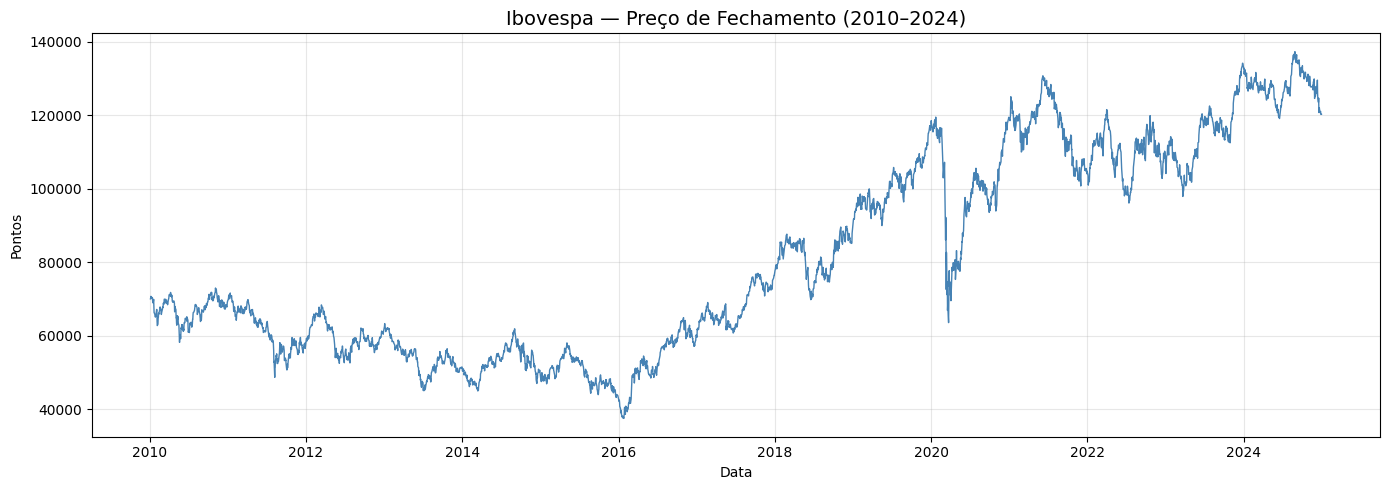

In [4]:
# Visualização da série histórica completa
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Close'], color='steelblue', linewidth=1)
ax.set_title('Ibovespa — Preço de Fechamento (2010–2024)', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Pontos')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Pré-processamento

Três etapas são necessárias antes de alimentar os dados na LSTM:

**Normalização:** redes neurais são sensíveis à escala dos inputs. Usamos o `MinMaxScaler` para comprimir os preços para o intervalo `[0, 1]`. É fundamental que o scaler seja ajustado **somente no conjunto de treino** para evitar *data leakage* — qualquer informação do futuro contaminando o modelo.

**Janelas deslizantes (sliding window):** a LSTM não recebe a série inteira de uma vez. Ela processa sequências de comprimento fixo. Para cada posição `t`, criamos um par:
- **X:** os 60 fechamentos anteriores (dias `t-60` até `t-1`)
- **y:** o fechamento do dia `t`

**Split temporal:** diferente de problemas tabulares, séries temporais não podem ser embaralhadas. O split deve respeitar a ordem cronológica: usamos 2010–2023 para treino e 2024 para teste.

In [5]:
# Parâmetro de janela temporal
WINDOW_SIZE = 60

# Split temporal: treino até 2023, teste em 2024
train_df = df[df.index.year < 2024]
test_df  = df[df.index.year == 2024]

print(f'Treino: {train_df.index.min().date()} → {train_df.index.max().date()} ({len(train_df)} pregões)')
print(f'Teste:  {test_df.index.min().date()} → {test_df.index.max().date()} ({len(test_df)} pregões)')

Treino: 2010-01-04 → 2023-12-28 (3464 pregões)
Teste:  2024-01-02 → 2024-12-30 (251 pregões)


In [6]:
# Normalização — scaler ajustado APENAS nos dados de treino
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['Close']])

# O set de teste inclui os últimos 60 dias do treino como contexto inicial
# para que a primeira previsão de 2024 tenha uma janela completa
full_test = pd.concat([train_df.tail(WINDOW_SIZE), test_df])
test_scaled = scaler.transform(full_test[['Close']])

print(f'Shape treino normalizado: {train_scaled.shape}')
print(f'Shape teste normalizado:  {test_scaled.shape}')

Shape treino normalizado: (3464, 1)
Shape teste normalizado:  (311, 1)


In [7]:
def create_sequences(data, window_size):
    """Converte uma série 1D em pares (X, y) usando janela deslizante."""
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

# A LSTM espera inputs no formato (batch, seq_len, features)
X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test  = X_test.reshape(-1, WINDOW_SIZE, 1)

# Conversão para tensores PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

print(f'X_train: {X_train_t.shape} | y_train: {y_train_t.shape}')
print(f'X_test:  {X_test_t.shape}  | y_test:  {y_test_t.shape}')

X_train: torch.Size([3404, 60, 1]) | y_train: torch.Size([3404])
X_test:  torch.Size([251, 60, 1])  | y_test:  torch.Size([251])


In [8]:
# Dataset e DataLoader para iterar em batches durante o treino
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TimeSeriesDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=False)

## 4. Arquitetura do Modelo

A LSTM é definida como uma subclasse de `nn.Module`, o padrão do PyTorch para qualquer modelo de deep learning. A arquitetura tem três componentes principais:

- **`nn.LSTM`:** a camada recorrente propriamente dita. Recebe a sequência de 60 dias e produz um estado oculto (`hidden state`) a cada passo de tempo. O `hidden_size` controla a dimensionalidade desse estado — quantas informações a célula de memória pode carregar. `num_layers` empilha múltiplas LSTMs, permitindo representações mais abstratas.

- **`nn.Dropout`:** regularização aplicada entre as camadas LSTM para reduzir overfitting. Desativa aleatoriamente uma fração dos neurônios durante o treino.

- **`nn.Linear`:** camada totalmente conectada que projeta o estado oculto final (do último passo de tempo) para uma única saída — o preço previsto normalizado.

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Camada LSTM: processa a sequência e mantém estado interno
        # batch_first=True → o tensor de input tem formato (batch, seq, features)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )

        # Camada de saída: mapeia o hidden state final → 1 valor previsto
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Inicializa os estados oculto (h0) e de célula (c0) com zeros
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Passa a sequência pela LSTM
        # out: (batch, seq_len, hidden_size) — saída em cada passo de tempo
        out, _ = self.lstm(x, (h0, c0))

        # Usamos apenas a saída do ÚLTIMO passo de tempo para a previsão
        out = self.fc(out[:, -1, :])
        return out.squeeze()


model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(model)
print(f'\nTotal de parâmetros: {sum(p.numel() for p in model.parameters()):,}')

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total de parâmetros: 50,497


## 5. Treinamento

O treinamento segue o loop padrão do PyTorch:

1. **Forward pass:** os inputs passam pelo modelo e geram previsões
2. **Cálculo do loss:** comparamos as previsões com os valores reais usando **MSE (Mean Squared Error)** — adequado para regressão, pois penaliza erros grandes proporcionalmente ao quadrado
3. **Backward pass:** o PyTorch calcula os gradientes via backpropagation through time (BPTT)
4. **Atualização dos pesos:** o otimizador **Adam** ajusta os parâmetros na direção que reduz o loss

Usamos também **gradient clipping** (`clip_grad_norm_`) para evitar o problema oposto ao vanishing gradient — o *exploding gradient*, onde gradientes muito grandes desestabilizam o treino.

In [ ]:
# Hiperparâmetros de treino
EPOCHS = 50
LR = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # Zera os gradientes acumulados
        predictions = model(X_batch)   # Forward pass
        loss = criterion(predictions, y_batch)  # Calcula o MSE
        loss.backward()                # Backward pass (BPTT)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()               # Atualiza os pesos
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_loss:.6f}')

print('\nTreinamento concluído.')

Epoch [10/50] | Loss: 0.029079
Epoch [20/50] | Loss: 0.000555
Epoch [30/50] | Loss: 0.000501
Epoch [40/50] | Loss: 0.000499
Epoch [50/50] | Loss: 0.000537

Treinamento concluído.


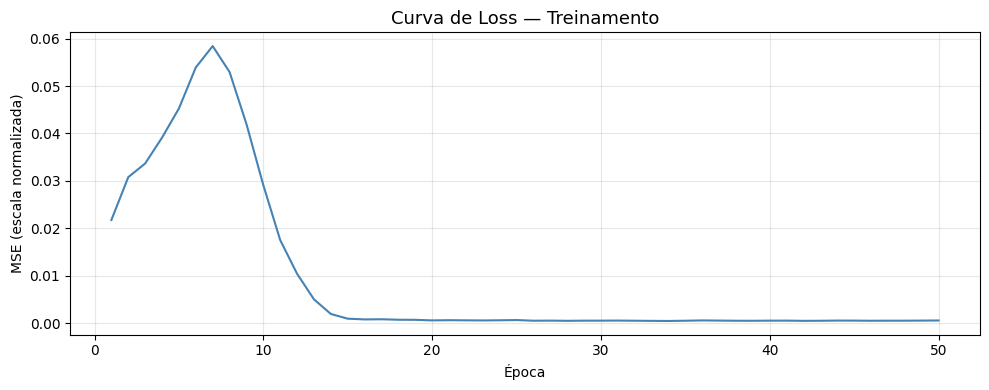

In [11]:
# Curva de loss ao longo das épocas
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', linewidth=1.5)
ax.set_title('Curva de Loss — Treinamento', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('MSE (escala normalizada)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Avaliação

Com o modelo treinado, geramos as previsões para o período de teste (2024) e revertemos a normalização para obter os valores na escala original de pontos do Ibovespa. As métricas usadas são:

- **RMSE (Root Mean Squared Error):** erro médio em pontos, na mesma escala do índice. Penaliza erros grandes mais do que o MAE.
- **MAE (Mean Absolute Error):** erro absoluto médio em pontos. Mais interpretável diretamente.

In [12]:
# Geração das previsões no set de teste
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).cpu().numpy()

# Inversão da normalização para escala original (pontos do Ibovespa)
preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
actual = test_df['Close'].values

# Métricas de avaliação
rmse = np.sqrt(mean_squared_error(actual, preds))
mae  = mean_absolute_error(actual, preds)

print(f'RMSE: {rmse:,.0f} pontos')
print(f'MAE:  {mae:,.0f} pontos')
print(f'Média do índice no período de teste: {actual.mean():,.0f} pontos')
print(f'RMSE relativo: {rmse / actual.mean() * 100:.2f}%')

RMSE: 1,355 pontos
MAE:  1,095 pontos
Média do índice no período de teste: 128,243 pontos
RMSE relativo: 1.06%


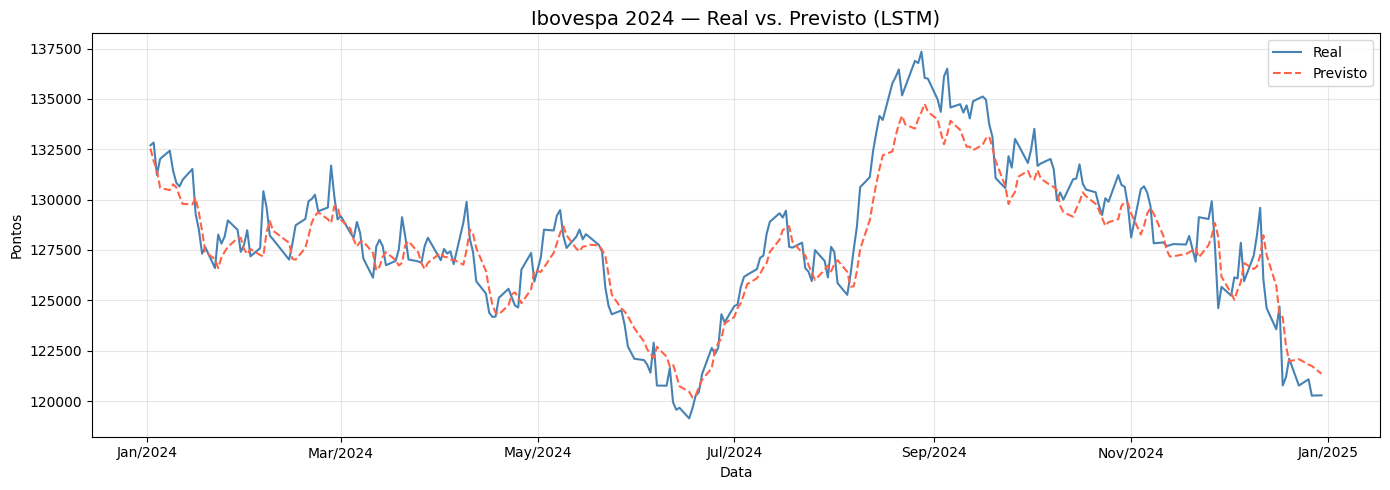

In [13]:
# Visualização: preço real vs. previsto em 2024
test_dates = test_df.index

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_dates, actual, label='Real',    color='steelblue', linewidth=1.5)
ax.plot(test_dates, preds,  label='Previsto', color='tomato',    linewidth=1.5, linestyle='--')

ax.set_title('Ibovespa 2024 — Real vs. Previsto (LSTM)', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Pontos')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

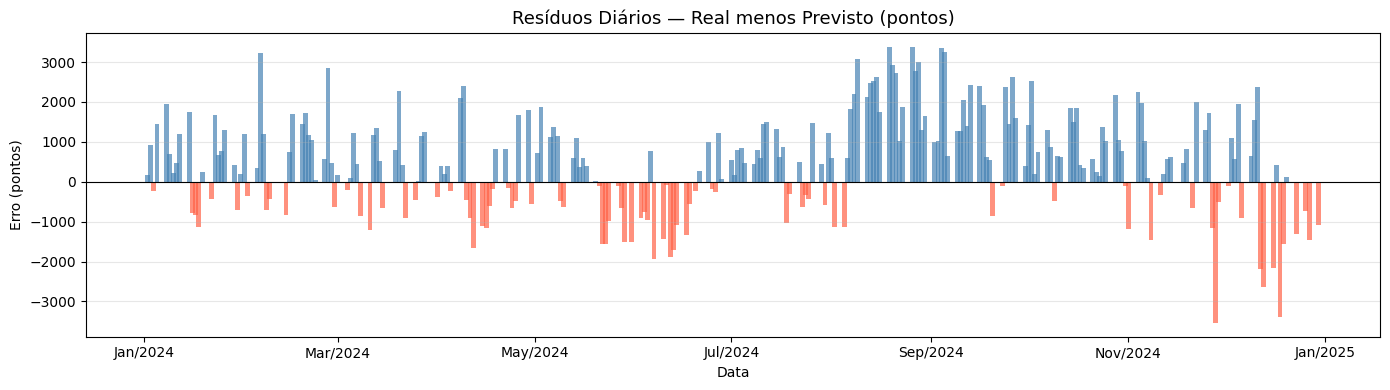

In [14]:
# Visualização do erro diário (residuals)
residuals = actual - preds

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(test_dates, residuals, color=np.where(residuals >= 0, 'steelblue', 'tomato'), alpha=0.7, width=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Resíduos Diários — Real menos Previsto (pontos)', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Erro (pontos)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Discussão Crítica

### O que o modelo captura bem

Em condições de mercado relativamente estável, a LSTM tende a acompanhar a tendência de curto prazo com razoável precisão — especialmente quando a série não sofre quebras estruturais abruptas. Isso ocorre porque a janela de 60 dias fornece contexto suficiente para o modelo aprender a dinâmica local da série.

### Limitações fundamentais

**O modelo é univariado.** Ele usa apenas o próprio histórico de preços do Ibovespa como input. Fatores como taxa Selic, câmbio, dados macroeconômicos e sentimento de mercado influenciam diretamente o índice, mas são invisíveis ao modelo.

**Previsões one-step-ahead não são previsões de fato.** Na prática, para prever o dia `t+1`, o modelo já conhece o preço real do dia `t`. O cenário mais realista — prever múltiplos dias consecutivos sem input real — degradaria significativamente a performance.

**Choques e eventos discretos são imprevisíveis.** Decisões do Copom, resultados eleitorais, crises externas e outros eventos discretos geram saltos na série que nenhum modelo puramente histórico consegue antecipar.

**A série financeira não é estacionária.** O Ibovespa em pontos tem uma tendência de longo prazo (crescimento nominal). Trabalhar com retornos percentuais ou com a série diferenciada seria metodologicamente mais rigoroso.